# 2.1 Transit light curve analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2025-2026 exercise 2

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

## Initialisation

In [1]:
import math as mt
import pandas as pd
import warnings
import seaborn as sb

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, array, median, seterr, floor, percentile
from numpy.random import seed, permutation
from astropy.table import Table
from corner import corner

from pytransit import TransitLPF

seterr('ignore')
seed(0)

/home/alessia/jupyter-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read in the data

First we need to read in the light curve stored in ``wasp-12b_181227_chromatic_k.fits``. The file has light curves for a single transit observed simultaneously in four passbands (g, r, i, and z_s), but we keep things simple and use only the r-band data. 

In our case, the photometry is saved as binary table extensions in the fits file, one extension per passband. To get the r-band data, we need to read the third HDU of the fits file (the first is the primary HDU, the second the first extension, etc.).

We start the same way as with the RV data and take a look at our data and try plotting it.

In [2]:
tb = Table.read('data/wasp-12b_181227_chromatic_k.fits', 2)
tb[:5]

time_bjd,flux,flux_rel,flux_trg,flux_ref,baseline,model
float64,float64,float64,float64,float64,float64,float64
2458480.557361179,1.0001350941062013,1.016282780690799,1.0234186998514527,1.0070215881802143,1.0161455054219737,1.0
2458480.558397079,1.0000222850175708,1.0167163747091499,1.0256873377854854,1.0088234667007323,1.0166937176717874,1.0
2458480.5587828704,0.999633046547194,1.0162828378132795,1.0244264276468822,1.0080131136044028,1.016655903207277,1.0
2458480.5594445122,1.0004227218395325,1.0169303171289636,1.0232086525273774,1.0061738108232814,1.016500620116942,1.0
2458480.5602084063,0.9981259684100012,1.0146302762017558,1.021813766379826,1.0070799091516973,1.0165352954577924,1.0


Now, we can assume the time data is stored in the ``time_bjd`` column and the flux the ``flux`` column. In general, if you'd see a file like this, you should check the file's documentation (if such exists) what column is what, or ask the person who created the file.

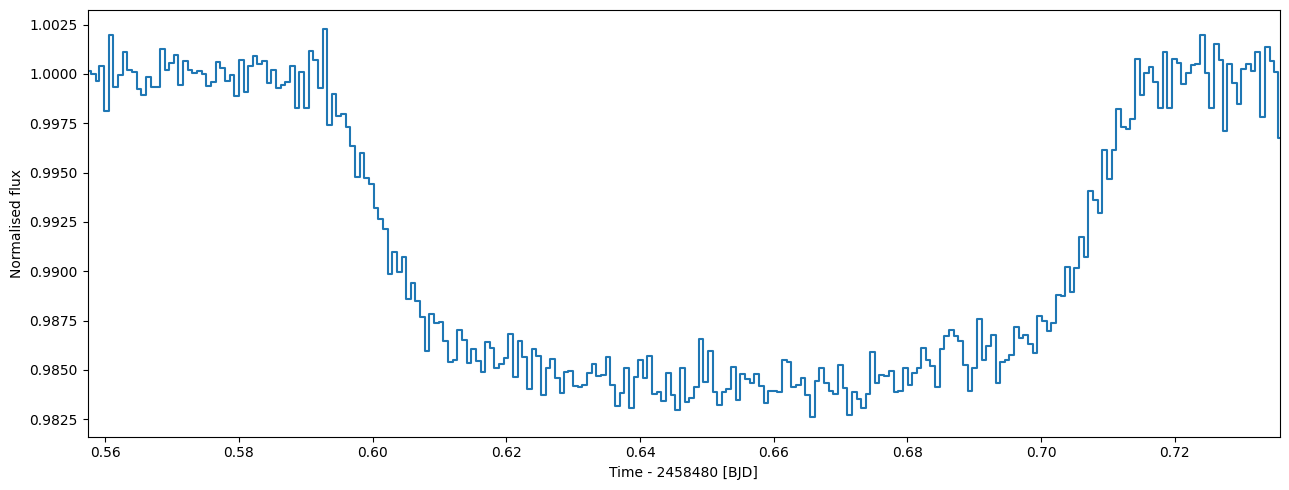

In [3]:
tref = floor(tb['time_bjd'].mean()) # floor approx by defect the mean value
fig, ax = subplots(figsize=(13,5), sharey=True)
ax.plot(tb['time_bjd'] - tref, tb['flux'], drawstyle='steps-mid') # with a stepped line
setp(ax, xlabel=f"Time - {tref:.0f} [BJD]", ylabel='Normalised flux', xlim=tb['time_bjd'][[0,-1]]-tref) # [0,-1] first and last time
fig.tight_layout()

## Parameter estimation

First, we create an instance of the log posterior function with the redmost light curve data.

Next, we run the *DE* optimiser for ``de_iter`` iterations to clump the parameter vector population close to the global posterior maximum, use the *DE* population to initialise the *emcee* sampler, and run the sampler for ``mc_iter`` iterations to obtain a posterior sample.

### Initialise the LPF and set the priors

In [4]:
lpf = TransitLPF('WASP-12b', 'r', tb['time_bjd'], tb['flux'])
lpf.ps

[  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

In [5]:
lpf.set_prior('tc', 'NP', 2458480.65, 0.02) # central time of transit (NP because I have an idea of the vale, unif when I don't)
lpf.set_prior('p', 'NP', 1.0914201, 1.1e-09) # orbital period

In [6]:
lpf.ps

[  0 |G| tc             N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p              N(μ = 1.0914201, σ = 1.1e-09)            [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

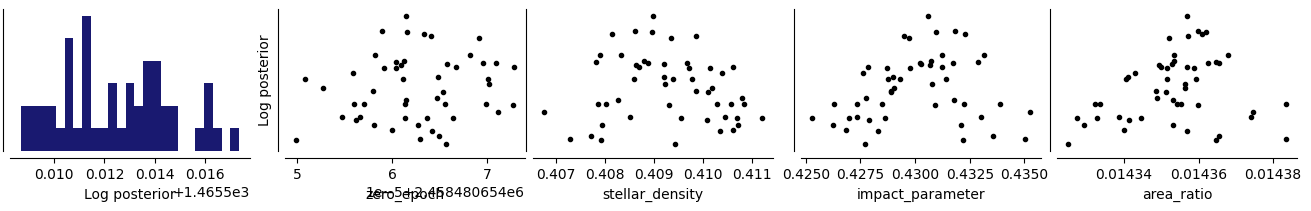

In [7]:
lpf.optimize_global(niter=500, npop=50)

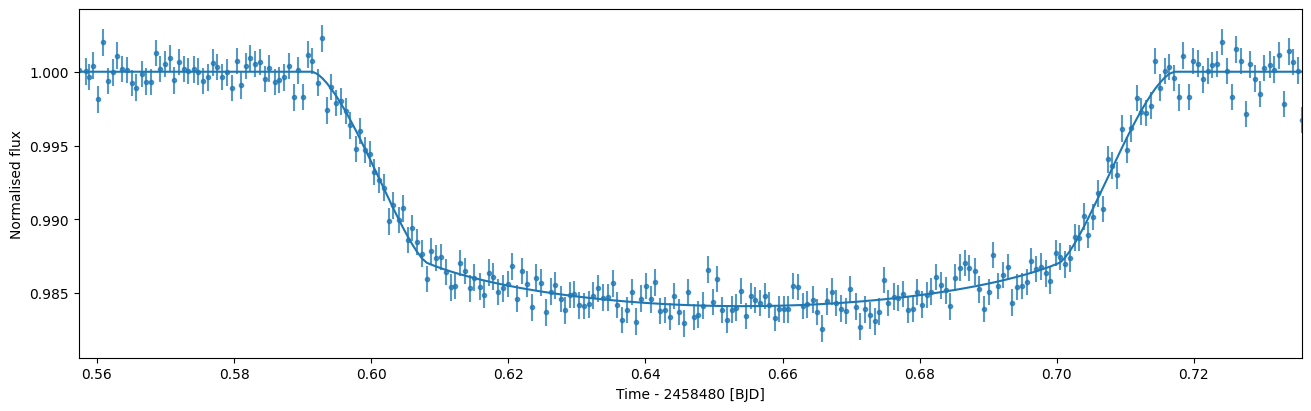

In [8]:
lpf.plot_light_curve();

In [9]:
lpf.sample_mcmc(5000, thin=20, repeats=2, label='MCMC sampling') # it starts from what is found with optimize_global

MCMC sampling: 100%|██████████████████████████████| 2/2 [00:07<00:00,  3.55s/it]


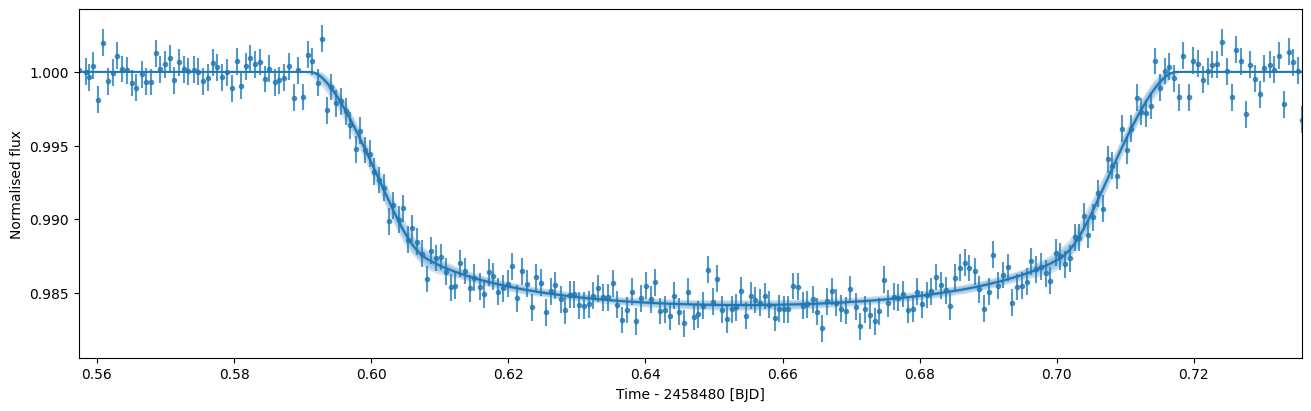

In [10]:
lpf.plot_light_curve('mc');

### Analysis: overview

The MCMC chains are now stored in ``lpf.sampler.chain``. Let's first have a look into how the chain populations evolved to see if we have any problems with our setup, whether we have converged to sample the true posterior distribution, and, if so, what was the burn-in time.

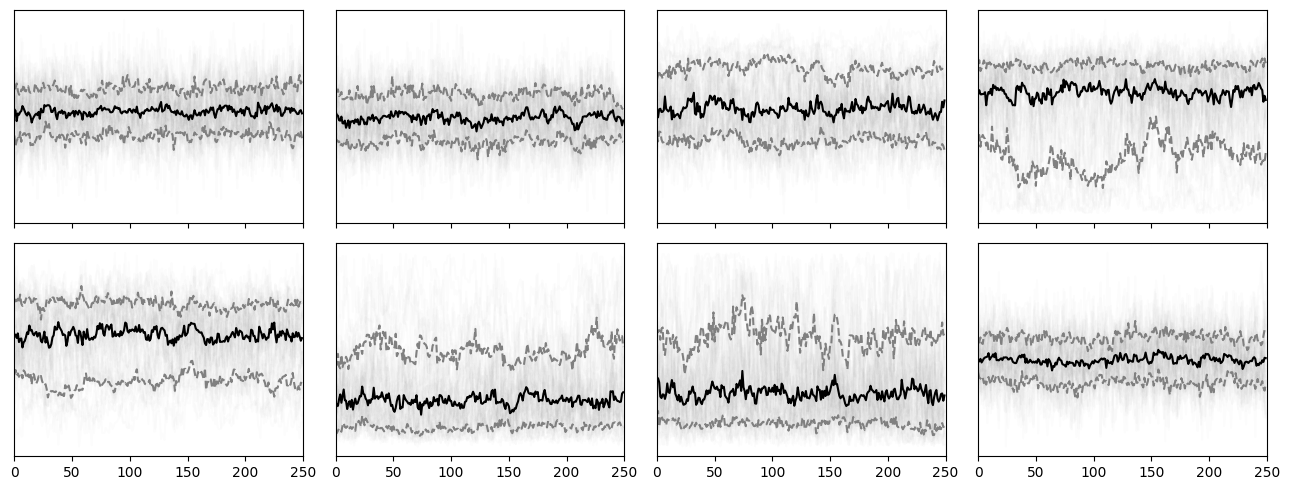

In [11]:
fig, axs = subplots(2,4, figsize=(13,5), sharex=True) # 8 plots bc of the 8 parameters, sharex=True to have the same x-axis
ls, lc = ['-','--','--'], ['k', '0.5', '0.5'] # ls = line styles and lc = line colour
percs = [percentile(lpf.sampler.chain[:,:,i], [50,16,84], 0) for i in range(8)] # for every chain I compute the mediane (50), low limit (16), high limit (84)
[axs.flat[i].plot(lpf.sampler.chain[:,:,i].T, 'k', alpha=0.01) for i in range(8)] # flat[i] means to take the plot i
[[axs.flat[i].plot(percs[i][j], c=lc[j], ls=ls[j]) for j in range(3)] for i in range(8)]
setp(axs, yticks=[], xlim=[0,5000//20])
fig.tight_layout()

Ok, everything looks good. The 16th, 50th and 84th percentiles of the parameter vector population are stable and don't show any significant long-term trends. Now we can flatten the individual chains into one long chain ``fc`` and calculate the median parameter vector.

In [12]:
fc = lpf.sampler.chain.reshape([-1,lpf.sampler.chain.shape[-1]]) # it put together the 2 chains for every parameter
# it is equal to reshape([-1, 8]) in which the columns are the parameters and it decides the number of rows(putting -1 means that9
mp = median(fc, 0) # 0 means to do the mean of the rows

Let's also plot the model and the data to see if this all makes sense. To do this, we calculate the conditional distribution of flux using the posterior samples (here, we're using a random subset of samples, although this isn't really necessary), and plot the distribution median and it's median-centred 68%, 95%, and 99.7% central posterior intervals (corresponding approximately to 1, 2, and 3$\sigma$ intervals if the distribution is normal). 

In [13]:
flux_pr = lpf.flux_model(fc[permutation(fc.shape[0])[:1000]]) # it permutates the rows and takes the first 1000, then it generates 1000 light curves
flux_pc = array(percentile(flux_pr, [50, 0.15,99.85, 2.5,97.5, 16,84], 0)) # it computes the statistics of flux_pr

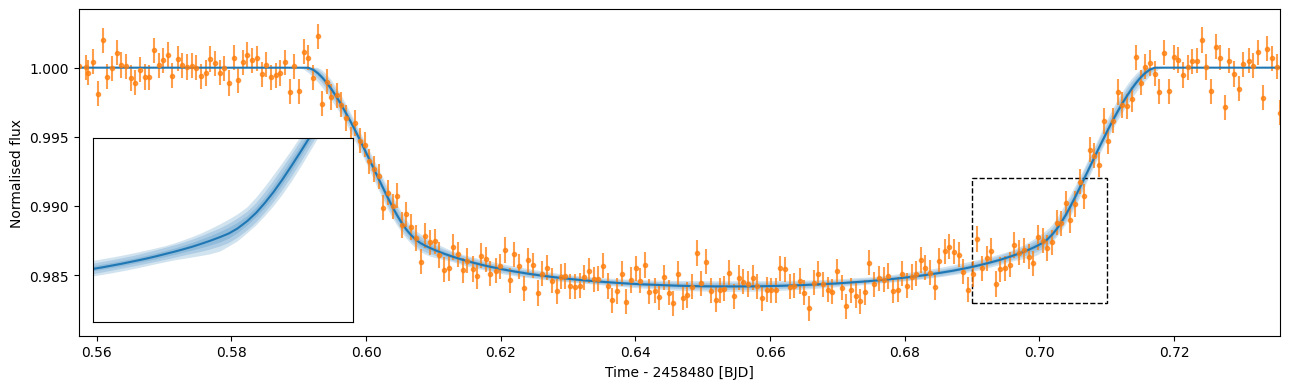

In [14]:
zx1,zx2,zy1,zy2 = 0.69,0.71, 0.983, 0.992 # region to zoom in (x,y) plane
tref = floor(lpf.timea.min()) # approx the min time
fig, ax = subplots(1,1, figsize=(13,4))
ax.errorbar(lpf.timea-tref, lpf.ofluxa, 10**mp[7], fmt='.', c='C1', alpha=0.75) # (centred time, obs flux, error, points, colour, trasparency)
[ax.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)] # from 0 to 6 with step 2, to take the right intervals
ax.plot(lpf.timea-tref, flux_pc[0], c='C0')
setp(ax, xlim=lpf.timea[[0,-1]]-tref, xlabel=f'Time - {tref:.0f} [BJD]', ylabel='Normalised flux')
fig.tight_layout()

az = fig.add_axes([0.075,0.18,0.20,0.46]) # it creates a subplot inside the figure
ax.add_patch(Rectangle((zx1,zy1),zx2-zx1,zy2-zy1,fill=False,edgecolor='k',lw=1,ls='dashed'))
[az.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)] # the same as before but on az
setp(az, xlim=(zx1,zx2), ylim=(zy1,zy2), yticks=[], xticks=[])
az.plot(lpf.timea-tref, flux_pc[0], c='C0');

We could (should) also plot the residuals, but I've left them out from the plot for clarity. The plot looks fine, and we can continue to have a look at the parameter estimates.

## Analysis

We start the analysis by making a Pandas data frame ``df``, using the ``df.describe`` to gen an overview of the estimates, and plotting the posteriors for the most interesting parameters as violin plots.

In [15]:
pd.set_option('display.precision',4) # with 4 decimals
df = lpf.posterior_samples(derived_parameters=True)
df.describe()

,tc,p,rho,b,k2,q1_r,q2_r,wn_loge_0,k,a,inc,t14,t23
count,1.2500e+04,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000
mean,2.4585e+06,1.0914e+00,0.4385,0.3230,0.0139,0.3242,3.3313e-01,-3.0400,0.1180,3.0200,1.4623,0.1257,0.0948
std,1.6276e-04,1.1102e-09,0.0377,0.1303,0.0005,0.1963,2.3105e-01,0.0189,0.0019,0.0866,0.0457,0.0009,0.0026
min,2.4585e+06,1.0914e+00,0.3200,0.0005,0.0126,0.0490,5.5725e-05,-3.1080,0.1123,2.7211,1.3573,0.1226,0.0869
25%,2.4585e+06,1.0914e+00,0.4097,0.2464,0.0136,0.1723,1.5406e-01,-3.0525,0.1165,2.9548,1.4275,0.1251,0.0928
50%,2.4585e+06,1.0914e+00,0.4353,0.3621,0.0140,0.2732,2.7309e-01,-3.0401,0.1183,3.0152,1.4505,0.1257,0.0945
75%,2.4585e+06,1.0914e+00,0.4687,0.4220,0.0143,0.4326,4.6280e-01,-3.0276,0.1195,3.0904,1.4910,0.1264,0.0969
max,2.4585e+06,1.0914e+00,0.5342,0.5764,0.0150,0.9968,9.9959e-01,-2.9561,0.1225,3.2282,1.5706,0.1298,0.1014


<Axes: >

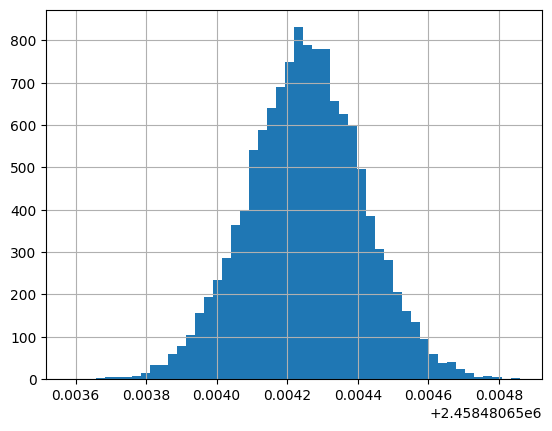

In [16]:
df.tc.hist(bins=50) # histogram od the central transit time

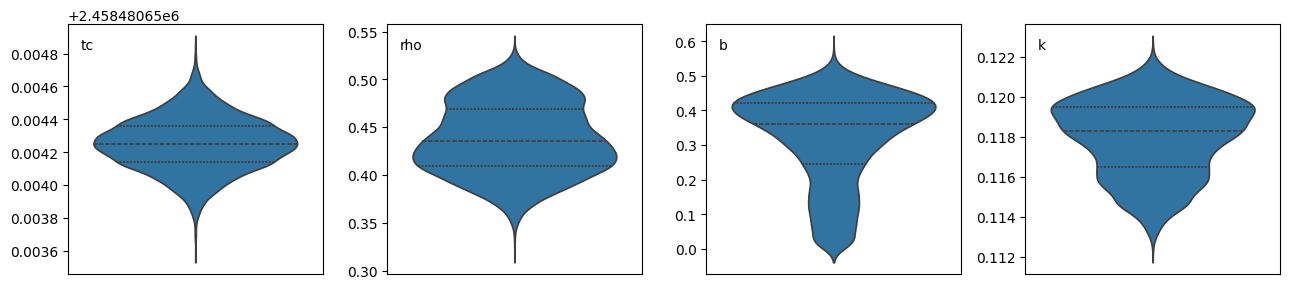

In [17]:
fig, axs = subplots(1,4, figsize=(13,3))
pars = 'tc rho b k'.split() # central transit time, stellar density, impact parameter, radius ratio
[sb.violinplot(y=df[p], inner='quartile', ax=axs.flat[i]) for i,p in enumerate(pars)]
[axs.flat[i].text(0.05,0.9, p, transform=axs.flat[i].transAxes) for i,p in enumerate(pars)] # I decide the exact position in which I want the labels 
setp(axs, xticks=[], ylabel='')
fig.tight_layout()

While we're at it, let's plot some correlation plots. The limb darkening coefficients are correlated, and we'd also expect to see a correlation between the impact parameter and radius ratio.

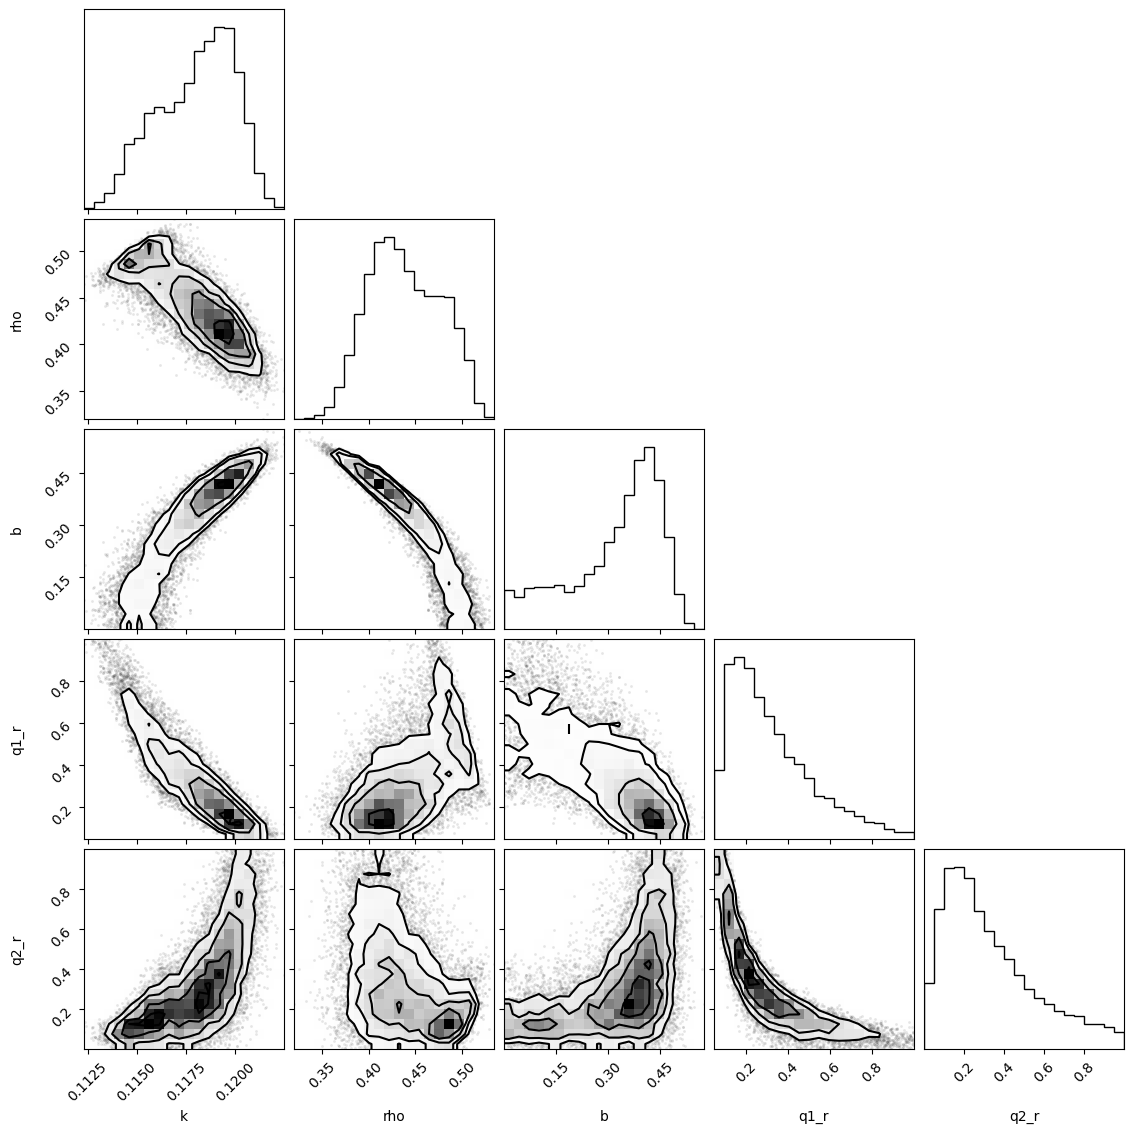

In [18]:
ccols = ['k', 'rho', 'b', 'q1_r', 'q2_r']
corner(df[ccols].values, labels=ccols);

### <span style="color:darkblue">Questions and exercises</span>

1. Estimate the radius of the planet using the planet-star radius ratio (k) and the stellar radius (that you need to find from somewhere) Give the answer in Jupiter radii.

In [23]:
import numpy as np
import astropy.units as u

R_star = 1.57 * u.R_sun # the radius of the star WASP-12 in solar radius
R_star_j = R_star.to(u.R_jup) 
k = df['k'].values

R_p = k * R_star_j
R_pv = R_p.value

R_p_median = np.median(R_pv)
R_p_low, R_p_high = np.percentile(R_pv, [16,84])

print(f"R_p = {R_p_median:.3f} (+{R_p_high-R_p_median:.3f}/-{R_p_median-R_p_low:.3f}) Rj")



R_p = 1.807 (+0.025/-0.038) Rj


2. Estimate the planet's bulk density based on the radius posterior and exercise 1 minimum mass estimate. Include the minimum mass estimate's uncertainty into the calculation.

In [24]:
import astropy.units as u

# Minimum mass M_p*sin(i) estimated in the exercise 1:
M_p = np.load("mass_samples.npy") 
print('M_p=',M_p)

# Randomly resample mass posterior to match radius samples
N = len(R_p)
M_p = np.random.choice(M_p, size=N, replace=True)* u.M_jup

# Computing the density
rho = M_p / (4/3 * np.pi * R_p**3)
rho = rho.to(u.g / u.cm**3).value

# median and sigma
rho_median = np.median(rho)
rho_low, rho_high = np.percentile(rho, [16,84])

print(f"rho_p = {rho_median:.3f} (+{rho_high-rho_median:.3f}/-{rho_median-rho_low:.3f}) g/cm^3")


M_p= [1.37841466 1.37812302 1.37512288 ... 1.35195017 1.34617407 1.35521745]
rho_p = 0.285 (+0.019/-0.012) g/cm^3


3. Why can we use the minimum mass estimate from RVs as a true mass estimate after a transit observation? Would there be better ways to estimate planetary properties than by modelling RVs and photometry separately?

- When we compute the mass of the exoplanet with the RV method, what we actually measure is the value of $M_p \, sin(i)$, where i is the inclination of the planet's orbit. At this point the inclination is unknown but this result gives us a lower limit for the mass, because $sin(i)<1$. But for a planet to transit, the inclination must be very close to 90°, which means $sin(i)\approx 1$. This is the reason why it is almost equal to the true planetary mass.\\
It would be better to estimate the planetary properties with a joint analysis of both RVs and photometry. In a joint model, all parameters are fitted simultaneously, allowing shared parameters to be constrained by both datasets and to take into account all the dependencies between the quantities. It also ensures that uncertainties are properly propagated.
Indeed in our case, to estimate the planet density, I combined the two distributions by randomly pairing mass and radius samples.
   
4. What can you say about WASP-12b as a planet based on its orbirtal period, radius, mass, and bulk density?

- Based on its properties, WASP-12b can be classified as an inflated hot Jupiter. Its short orbital period indicates that the planet orbits very close to the star, which results in intense stellar irradiation and consequently very high temperatures. In addition it has a mass of around 1.36 $M_j$, which means that we are observing a massive exoplanet. But it also has a large radius of around 1.8 $R_j$, which, combined with the low bulk density, indicate that the planet is a gas giant. Since the radius does not increase significantly with mass, due to gravitational compression, then it probably means that it has an expanded atmosphere, most likely due to strong stellar irradiation. This is the reason why it is called "inflated".

5. Compare the stellar density ($\rho$) estimated from the transit modelling to the theoretical stellar density for a WASP-12-like star.
  
- The stellar density estimated from the transit is $\approx 0.285 \, \text{g/cm}^3$, while the theoretical value is $\approx 0.266 \, \text{g/cm}^3$, showing good agreement between the two. The stellar density derived from transit modelling can be obtained directly from the transit shape and the orbital period, both inferred from the light curve. This close match between the values indicates that the assumed orbital configuration and the transit model are reliable.

6. From the plot above you can see that many of the parameters are correlated with each other. What does this mean in practice?

- The presence of correlations between parameters means that they are not independent, but are instead linked through the physics of the model. In practice, this implies that different combinations of parameters can produce equally good fits to the data and therefore a change in one parameter can be compensated by adjustments in others. As a consequence, uncertainties cannot be interpreted independently for each parameter, since they depend on the values of the others. Ignoring these correlations would typically lead to underestimated or misleading uncertainties.


---
<center>&copy;2026 Hannu Parviainen</center>